In [1]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/My Drive/[2024-2025] AN2DL HOMEWORK 1

Mounted at /gdrive
/gdrive/My Drive/[2024-2025] AN2DL HOMEWORK 1


In [2]:
# Fix randomness and hide warnings
SEED = 42  # Random seed for reproducibility

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras as tfk
from tensorflow.keras import layers as tfkl
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set seed for TensorFlow
tf.random.set_seed(SEED)
tf.compat.v1.set_random_seed(SEED)

# Reduce TensorFlow verbosity
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Print TensorFlow version
print(tf.__version__)

# Import other libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
from PIL import Image
import matplotlib.gridspec as gridspec
from datetime import datetime

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

2.17.0


In [3]:
# Load data
data = np.load('training_set.npz')
X = data['images']
y = data['labels']

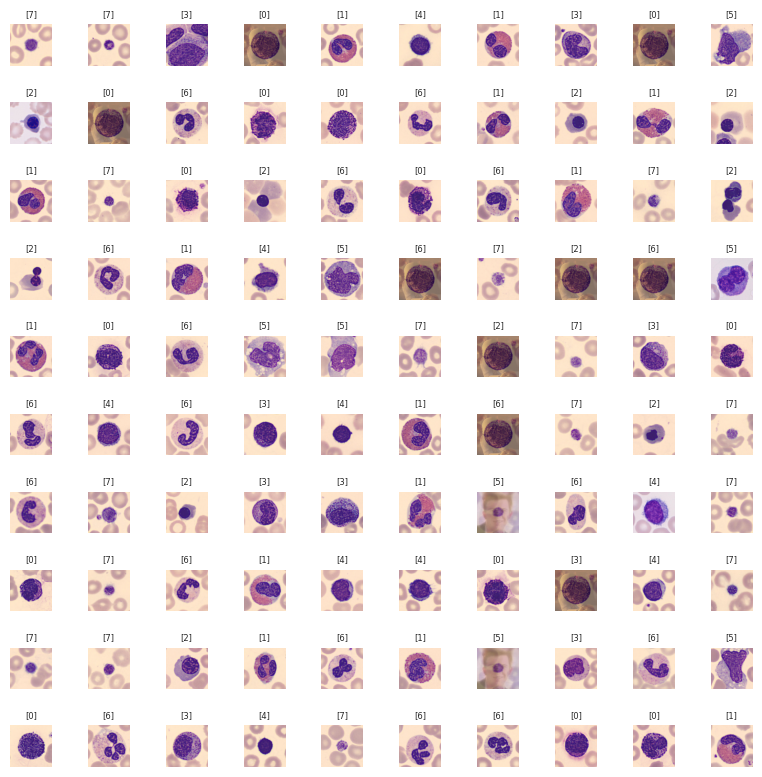

In [4]:
def display_images(X, y, num_img=100):
    """
    Display images in a square grid, handling normalization if necessary.

    Parameters:
        X (array-like): Array of images (can be normalized between [0, 1] or in the range [0, 255]).
        y (array-like): Array of labels corresponding to the images.
        num_img (int): Number of images to display (default is 100).
    """
    grid_size = int(np.ceil(np.sqrt(num_img)))  # Calculate grid size for a square layout
    random_indices = random.sample(range(len(X)), num_img)  # Randomly select images

    # Create subplots
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))

    for i, idx in enumerate(random_indices):
        ax = axes[i // grid_size, i % grid_size]  # Locate subplot

        # Handle normalization: convert [0, 1] range to [0, 255] if necessary
        img = X[idx]
        if img.max() <= 1.0:
            img = np.clip(img, 0, 1) * 255
        else:
            img = np.clip(img, 0, 255)

        # Display image
        ax.imshow(img.astype(np.uint8))
        ax.set_title(f'{y[idx]}', fontsize=6)  # Set title with smaller font size
        ax.axis('off')  # Turn off axis

    # Turn off unused subplots
    for j in range(num_img, grid_size * grid_size):
        fig.delaxes(axes[j // grid_size, j % grid_size])

    plt.tight_layout()
    plt.show()

display_images(X, y, 100)

# Data Preprocessing

## Outliers and Duplicates Removal

In [5]:
# Remove outliers
X_out = X[:13559]
y_out = y[:13559]

# Remove duplicates
X = X_out[:11960]
y = y_out[:11960]

# Usa np.unique per trovare indici delle immagini uniche
_, unique_indices = np.unique(X.reshape(len(X), -1), axis=0, return_index=True)

# Estrai le immagini e le etichette corrispondenti agli indici unici
X = X[unique_indices]
y = y[unique_indices]

In [6]:
# Train val split
X_train, X_val, y_train, y_val = [], [], [], []

# Shuffle
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]

# Select exactly 'n' instances per class for validation
TARGET_ON_MINORITY = 0.2
class_counts = np.bincount(np.ravel(y))
minority_class_count = min(class_counts)
target_count = int(minority_class_count * TARGET_ON_MINORITY)

for class_label in np.unique(y):
    # Get all indices for the current class
    class_indices = np.where(y == class_label)[0]

    # Shuffle to ensure randomness in selection
    np.random.shuffle(class_indices)

    # Select n instances for the validation set
    val_indices = class_indices[:target_count]

    # Add selected validation instances to the validation list
    X_val.append(X[val_indices])
    y_val.append(y[val_indices])

    # The remaining instances are used for training
    train_indices = class_indices[target_count:]
    X_train.append(X[train_indices])
    y_train.append(y[train_indices])

# Combine the lists back into arrays
X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)
X_val = np.concatenate(X_val, axis=0)
y_val = np.concatenate(y_val, axis=0)

# Shuffle
indices_train = np.random.permutation(len(X_train))
indices_val = np.random.permutation(len(X_val))
X_train = X_train[indices_train]
y_train = y_train[indices_train]
X_val = X_val[indices_val]
y_val = y_val[indices_val]

# Print shapes of the datasets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (10600, 96, 96, 3), y_train shape: (10600, 1)
X_val shape: (1352, 96, 96, 3), y_val shape: (1352, 1)


## Dataset Unbalance Management

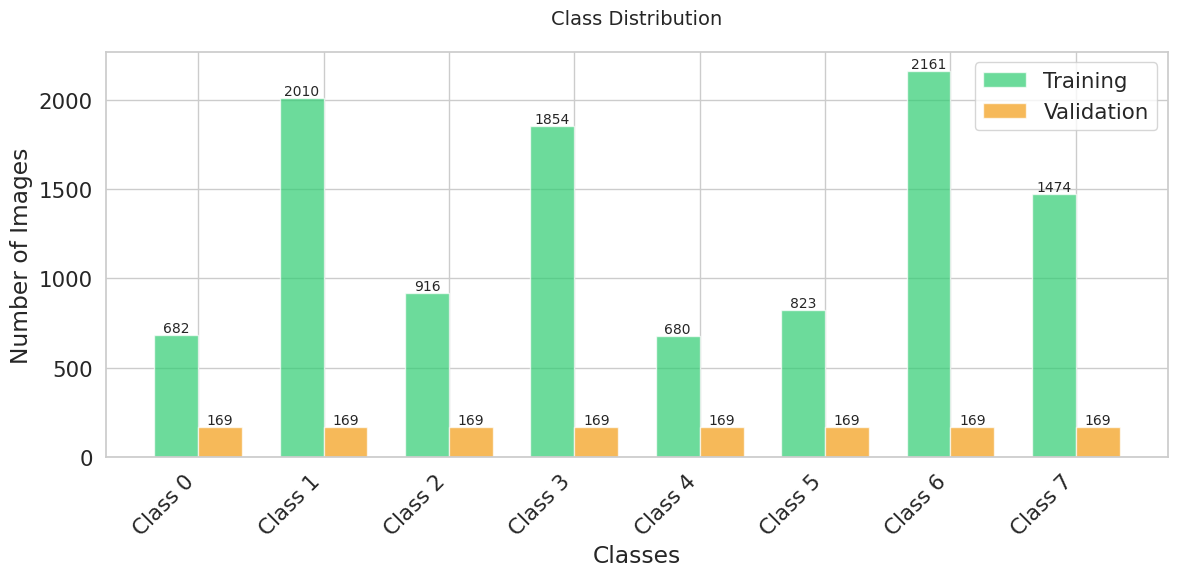

In [7]:
def plot_class_distribution(y_train, y_val, class_names):
    # Ensure that the inputs are 1D arrays of integers
    y_train = np.ravel(y_train).astype(int)
    y_val = np.ravel(y_val).astype(int)

    # Set seaborn style for the plot
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 6))

    # Calculate class distributions for training and validation sets
    train_dist = np.bincount(y_train, minlength=len(class_names))
    val_dist = np.bincount(y_val, minlength=len(class_names))

    # Create x positions and set bar width
    x = np.arange(len(class_names))
    width = 0.35

    # Plot bars for training and validation distributions
    bars_train = plt.bar(x - width/2, train_dist, width, label='Training', color='#2ecc71', alpha=0.7)
    bars_val = plt.bar(x + width/2, val_dist, width, label='Validation', color='#f39c12', alpha=0.7)

    # Add count annotations on top of the bars
    for bars in [bars_train, bars_val]:
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05,  # Offset above the bar
                     f'{int(yval)}', ha='center', va='bottom', fontsize=10)

    # Customise plot title and labels
    plt.title('Class Distribution', pad=20, fontsize=14)
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')

    # Set class names as x-axis labels with rotation
    plt.xticks(x, class_names, rotation=45, ha='right')

    # Add legend for training and validation distributions
    plt.legend(loc='upper right')

    # Adjust layout for optimal spacing
    plt.tight_layout()
    plt.show()

# Assuming `y_train` and `y_val` are now class indices directly
class_names = [f"Class {i}" for i in range(len(np.unique(y_train)))]  # Adjust this for actual class names if needed
plot_class_distribution(y_train, y_val, class_names)

I want to oversample the training data:
- data augmentation
- SMOTE on feature vector from a pretrained model

### Data Augmentation

In [8]:
def augment_class(X, y, target_class, target_count):
    """
    Augment images for a specific class to reach the target count.

    Parameters:
        X (array-like): Array of images.
        y (array-like): Array of labels.
        target_class (int): The class to augment.
        target_count (int): The desired number of samples for the class.

    Returns:
        X_augmented (numpy.ndarray): Augmented images for the target class.
        y_augmented (numpy.ndarray): Labels for the augmented images.
    """
    # Flatten `y` to ensure compatibility
    y_flat = np.ravel(y)
    target_indices = np.where(y_flat == target_class)[0]
    X_target = X[target_indices]

    # Create an ImageDataGenerator for augmentation
    datagen = ImageDataGenerator(
        rotation_range=30,
        # width_shift_range=0.2,
        # height_shift_range=0.2,
        # shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Calculate the number of samples to generate
    num_to_generate = target_count - len(target_indices)

    # Generate augmented images and labels
    augmented_images = []
    augmented_labels = []

    # Create batches of augmented images
    for X_batch, _ in zip(datagen.flow(X_target, batch_size=1, shuffle=True), range(num_to_generate)):
        img = np.clip(X_batch[0], 0, 255).astype(X.dtype)
        augmented_images.append(img)
        augmented_labels.append(target_class)

    X_augmented = np.array(augmented_images)
    y_augmented = np.array(augmented_labels).reshape(-1, 1)  # Ensure y_augmented has shape (N, 1)

    # Remove the extra batch dimension from the augmented images
    # X_augmented = np.squeeze(X_augmented, axis=1)

    return X_augmented, y_augmented

# Function to augment all classes and return the augmented data
def augment_all_classes(X, y, target_count):
    """
    Augment images for a specific class to reach the target count.

    Parameters:
        X (array-like): Array of images.
        y (array-like): Array of labels.
        target_class (int): The class to augment.
        target_count (int): The desired number of samples for the class.

    Returns:
        X_augmented (numpy.ndarray): Augmented images for the target class.
        y_augmented (numpy.ndarray): Labels for the augmented images.
    """
    # Ensure `y` is a 1D array of class indices
    y = np.ravel(y)  # Flatten y if it's a 2D array with one column

    # Count the number of occurrences of each class
    class_counts = np.bincount(y)  # Now y should be a 1D array of class indices

    # Initialize lists to hold augmented data
    X_augmented_all = []
    y_augmented_all = []

    # For each class, if the count is less than the target count, augment it
    for target_class in range(len(np.unique(y))):  # Use class indices directly
        if class_counts[target_class] < target_count:
            print(f"Class {target_class} has {class_counts[target_class]} samples. Augmenting to {target_count} samples.")
            X_augmented, y_augmented = augment_class(X, y, target_class, target_count)
            X_augmented_all.append(X_augmented)
            y_augmented_all.append(y_augmented)
        else:
            print(f"Class {target_class} already has {class_counts[target_class]} samples. No augmentation needed.")

    # Concatenate all augmented data
    if X_augmented_all:
        X_augmented_all = np.concatenate(X_augmented_all, axis=0)
        y_augmented_all = np.concatenate(y_augmented_all, axis=0)
    else:
        X_augmented_all = np.empty((0,) + X.shape[1:], dtype=X.dtype)
        y_augmented_all = np.empty((0, 1), dtype=y.dtype)  # Match (N, 1) shape

    return X_augmented_all, y_augmented_all

# Set target count for all classes to be 120% of the majority class count
TARGET_ON_MAJORITY = 1
class_counts = np.bincount(np.ravel(y_train))  # Flatten y_train if needed
majority_class_count = max(class_counts)
target_count = int(majority_class_count * TARGET_ON_MAJORITY)

# Augment all classes
X_augmented, y_augmented = augment_all_classes(X_train, y_train, target_count)

# Concatenate augmented data with the original dataset
X_train_augmented = np.concatenate((X_train, X_augmented), axis=0)
y_train_augmented = np.concatenate((y_train, y_augmented), axis=0)

# # Save the augmented data to an .npz file
# file_name = f'augmented_data_{datetime.now().strftime("%y%m%d_%H%M%S")}'
# np.savez(file_name, images=X_augmented, labels=y_augmented)

Class 0 has 682 samples. Augmenting to 2161 samples.
Class 1 has 2010 samples. Augmenting to 2161 samples.
Class 2 has 916 samples. Augmenting to 2161 samples.
Class 3 has 1854 samples. Augmenting to 2161 samples.
Class 4 has 680 samples. Augmenting to 2161 samples.
Class 5 has 823 samples. Augmenting to 2161 samples.
Class 6 already has 2161 samples. No augmentation needed.
Class 7 has 1474 samples. Augmenting to 2161 samples.


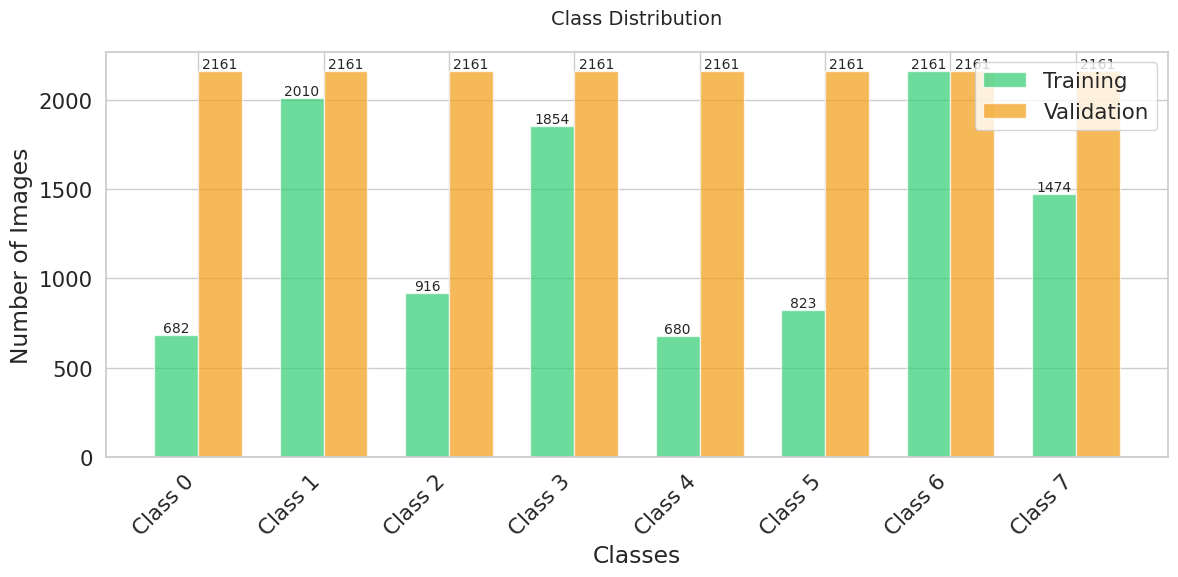

In [9]:
# Example usage
class_names = [f"Class {i}" for i in range(len(np.unique(y_train)))]  # Adjust for class names
plot_class_distribution(y_train, y_train_augmented, class_names)

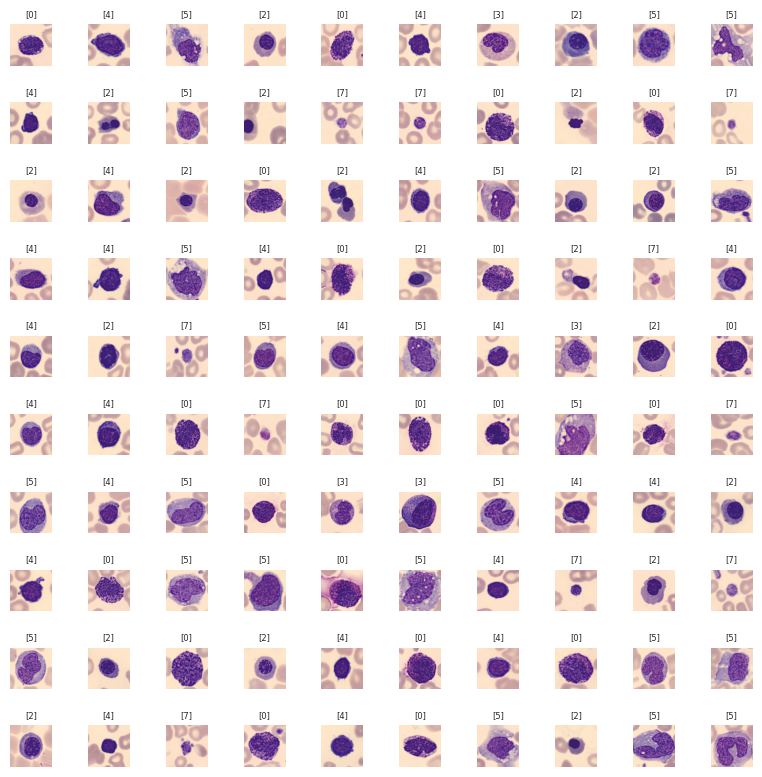

In [10]:
# Display augmented images
display_images(X_augmented, y_augmented, 100)

In [11]:
import numpy as np
from hashlib import sha256

def image_to_hash(image):
    """
    Convert an image to a hash for comparison.
    We use SHA-256 to generate a hash based on the image's flattened array.
    """
    # Flatten the image and encode it as bytes
    image_bytes = image.tobytes()

    # Generate the hash
    image_hash = sha256(image_bytes).hexdigest()

    return image_hash

def find_duplicate_images(X):
    """
    Find and return indices of duplicate images in an array of images X.

    Parameters:
        X (numpy.ndarray): Array of images with shape (num_images, height, width, channels)

    Returns:
        duplicate_indices (list): List of indices of duplicate images
    """
    # Store hashes of images to check for duplicates
    image_hashes = {}
    duplicate_indices = []

    # Loop through the images and hash each image
    for idx, image in enumerate(X):
        image_hash = image_to_hash(image)

        # Check if the hash is already in the dictionary
        if image_hash in image_hashes:
            # If it is, it's a duplicate, so store the index
            duplicate_indices.append(idx)
        else:
            # Otherwise, store the hash with the image's index
            image_hashes[image_hash] = idx

    return duplicate_indices

# Example usage with a dataset of images X
# Assuming X is a numpy array of shape (num_images, height, width, channels)
duplicate_indices = find_duplicate_images(X_train_augmented)

# Output duplicate indices
if duplicate_indices:
    print(f"Duplicate images found at indices: {duplicate_indices}")
else:
    print("No duplicates found.")


No duplicates found.


All good, now I have a balanced dataset with no duplicates and outliers.

### Feature Vector SMOTE

In [12]:
# from imblearn.over_sampling import SMOTE

# # Assuming X and y are your tabular data and labels
# smote = SMOTE(random_state=SEED)
# X_resampled, y_resampled = smote.fit_resample(X, y)


# Model

In [13]:
# Convert class labels to categorical format for training, validation, and test sets
y_train_augmented = tfk.utils.to_categorical(y_train_augmented.ravel(), num_classes=len(np.unique(y_train_augmented)))
y_val = tfk.utils.to_categorical(y_val.ravel(), num_classes=len(np.unique(y_val)))

# Print shapes of the datasets
print(f"X_train shape: {X_train_augmented.shape}, y_train shape: {y_train_augmented.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (17288, 96, 96, 3), y_train shape: (17288, 8)
X_val shape: (1352, 96, 96, 3), y_val shape: (1352, 8)


In [14]:
# Parameters
INPUT_SHAPE = X_train_augmented.shape[1:]
OUTPUT_SHAPE = y_train_augmented.shape[1]
LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.4
BATCH_SIZE = 256
EPOCHS = 1000
FINE_TUNE_EPOCHS = 200
PATIENCE = 20

# Initialise configuration for convolutional layers
STACK = 1
FILTERS = 32
KERNEL_SIZE = 3

# Create an EarlyStopping callback
early_stopping = tfk.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=PATIENCE,
    restore_best_weights=True
)
callbacks = [early_stopping]

# # Calculate class weights to handle imbalance
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.arange(y_augmented.shape[1]),
#     y=np.argmax(y_augmented, axis=1)
# )
# class_weights_dict = {i: class_weights[i] for i in range(NUM_CLASSES)}

print("Input Shape:", INPUT_SHAPE)
print("Output Shape:", OUTPUT_SHAPE)

Input Shape: (96, 96, 3)
Output Shape: 8


## MobileNetV3

In [15]:
# # Define the MobileNetV3 block with configurable parameters
# def mobilenetv3_block(x, filters, kernel_size=3, padding='same',
#                       downsample=True, activation='relu', stack=1, name='mobilev3', dropout_rate=0.2):

#     # Define h-swish activation function
#     def h_swish(x):
#         return x * tf.nn.relu6(x + 3.0) / 6.0

#     # Select activation function
#     activation_fn = tf.nn.relu if activation == 'relu' else h_swish

#     for s in range(stack):
#         input_channels = x.shape[-1]
#         residual = x

#         # Set expansion factor based on channel dimensions
#         expansion_factor = 1 if input_channels == filters else 6
#         expanded_channels = input_channels * expansion_factor

#         # Expansion phase
#         if expansion_factor != 1:
#             x = tfkl.Conv2D(expanded_channels, 1, padding=padding, use_bias=False, name=f'{name}_expand_{s}')(x)
#             x = tfkl.BatchNormalization(name=f'{name}_bn1_{s}')(x)
#             x = tfkl.Activation(activation_fn, name=f'{name}_act1_{s}')(x)
#             x = tfkl.Dropout(dropout_rate, name=f'{name}_dropout1_{s}')(x)  # Add dropout layer

#         # Depthwise convolution with optional downsampling
#         stride = 2 if (downsample and s == 0) else 1
#         x = tfkl.DepthwiseConv2D(kernel_size, strides=stride, padding=padding, use_bias=False, name=f'{name}_depthwise_{s}')(x)
#         x = tfkl.BatchNormalization(name=f'{name}_bn2_{s}')(x)
#         x = tfkl.Activation(activation_fn, name=f'{name}_act2_{s}')(x)
#         x = tfkl.Dropout(dropout_rate, name=f'{name}_dropout2_{s}')(x)  # Add dropout layer

#         # Squeeze-and-Excitation module
#         se_channels = max(1, expanded_channels // 4)
#         se = tfkl.GlobalAveragePooling2D(name=f'{name}_se_pool_{s}')(x)
#         se = tfkl.Reshape((1, 1, expanded_channels))(se)
#         se = tfkl.Conv2D(se_channels, 1, activation='relu', name=f'{name}_se_reduce_{s}')(se)
#         se = tfkl.Conv2D(expanded_channels, 1, activation='hard_sigmoid', name=f'{name}_se_expand_{s}')(se)
#         x = tfkl.Multiply(name=f'{name}_se_excite_{s}')([x, se])

#         # Projection phase to desired filter dimension
#         x = tfkl.Conv2D(filters, 1, padding=padding, use_bias=False, name=f'{name}_project_{s}')(x)
#         x = tfkl.BatchNormalization(name=f'{name}_bn3_{s}')(x)

#         # Add skip connection if applicable
#         if stride == 1 and input_channels == filters:
#             x = tfkl.Add(name=f'{name}_add_{s}')([residual, x])

#     return x

# # Define the model
# input_layer = tfkl.Input(shape=INPUT_SHAPE, name='input_layer')
# x = mobilenetv3_block(x=input_layer, filters=FILTERS, kernel_size=KERNEL_SIZE, downsample=False, name='block0', dropout_rate=DROPOUT_RATE)
# x = tfkl.GlobalAveragePooling2D(name='gap')(x)
# x = tfkl.Dropout(0.2, name='dropout_dense')(x)  # Add dropout layer before dense layer
# x = tfkl.Dense(1024, activation='relu', name='dense_1')(x)  # Add a dense layer with 1024 units and ReLU activation
# x = tfkl.Dropout(0.5, name='dropout_output')(x)  # Add dropout layer before output layer
# x = tfkl.Dense(OUTPUT_SHAPE, name='dense_output')(x)  # Final dense layer for output
# x = tfkl.Activation('softmax', name='softmax')(x)  # Apply softmax activation to output

# # Create the model
# model = tfk.Model(inputs=input_layer, outputs=x, name='architecture')

# # Compile the model
# loss = tfk.losses.CategoricalCrossentropy()
# optimizer = tfk.optimizers.Adam(LEARNING_RATE)
# metrics = ['accuracy']
# model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

# # Display model summary and plot
# model.summary(expand_nested=True, show_trainable=True)
# # tfk.utils.plot_model(model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

In [16]:
# # Train the model with early stopping callback
# history = model.fit(
#     x=X_train_augmented,
#     y=y_train_augmented,
#     batch_size=BATCH_SIZE,
#     epochs=EPOCHS,
#     validation_data=(X_val, y_val),
#     callbacks=callbacks
# ).history

# # Calculate and print the final validation accuracy
# final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)
# print(f'Final validation accuracy: {final_val_accuracy}%')

# # Save the trained model to a file with the accuracy included in the filename
# model_filename = 'MobileNetV3_'+str(final_val_accuracy)+'.keras'
# model.save(model_filename)

# # Delete the model to free up resources
# del model

In [17]:
# # Plot training and validation loss
# plt.figure(figsize=(12, 2))
# plt.plot(history['loss'], label='Training loss', alpha=.8)
# plt.plot(history['val_loss'], label='Validation loss', alpha=.8)
# plt.title('Loss')
# plt.legend()
# plt.grid(alpha=.3)

# # Plot training and validation accuracy
# plt.figure(figsize=(12, 2))
# plt.plot(history['accuracy'], label='Training accuracy', alpha=.8)
# plt.plot(history['val_accuracy'], label='Validation accuracy', alpha=.8)
# plt.title('Accuracy')
# plt.legend()
# plt.grid(alpha=.3)
# plt.show()

## ResNet50 Fine Tuning

In [18]:
# Parameters
FINE_TUNE_LEARNING_RATE = 1e-4
FINE_TUNE_EPOCHS = 200
FREEZE_NUM = 113

In [20]:
base_model = tfk.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers in the base model
base_model.trainable = False

input_layer = tfkl.Input(shape=INPUT_SHAPE, name='input_layer')
x = tfkl.Rescaling(1.0 / 255)(input_layer)
x = base_model(x)
x = tfkl.GlobalAveragePooling2D(name='gap')(x)
x = tfkl.Dropout(0.2, name='dropout_dense')(x)  # Add dropout layer before dense layer
x = tfkl.Dense(1024, activation='relu', name='dense_1')(x)  # Add a dense layer with 1024 units and ReLU activation
x = tfkl.Dropout(0.5, name='dropout_output')(x)  # Add dropout layer before output layer
x = tfkl.Dense(OUTPUT_SHAPE, name='dense_output')(x)  # Final dense layer for output
x = tfkl.Activation('softmax', name='softmax')(x)  # Apply softmax activation to output

# Create the model
model = tfk.Model(inputs=input_layer, outputs=x, name='architecture')

# Compile the model with a low learning rate
loss = tfk.losses.CategoricalCrossentropy()
optimizer = tfk.optimizers.Adam(LEARNING_RATE)
metrics = ['accuracy']
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Display model summary and plot
model.summary(expand_nested=True, show_trainable=True)

Model: "architecture"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer (InputLayer)            │ (None, 96, 96, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_1 (Rescaling)             │ (None, 96, 96, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ resnet50 (Functional)               │ (None, 3, 3, 2048)           │    23,587,712 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ input_layer_1 (InputLayer)     │ (None, 96, 96, 3)            │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv1_pad (ZeroPadding2D)      │ (None, 102, 102, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv1_conv (Conv2D)            │ (None, 48, 48, 64)           │         9,472 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv1_bn (BatchNormalization)  │ (None, 48, 48, 64)           │           256 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv1_relu (Activation)        │ (None, 48, 48, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ pool1_pad (ZeroPadding2D)      │ (None, 50, 50, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ pool1_pool (MaxPooling2D)      │ (None, 24, 24, 64)           │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_1_conv (Conv2D)   │ (None, 24, 24, 64)           │         4,160 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_1_bn              │ (None, 24, 24, 64)           │           256 │    N    │
│ (BatchNormalization)                │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_1_relu            │ (None, 24, 24, 64)           │             0 │    -    │
│ (Activation)                        │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_2_conv (Conv2D)   │ (None, 24, 24, 64)           │        36,928 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_2_bn              │ (None, 24, 24, 64)           │           256 │    N    │
│ (BatchNormalization)                │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_2_relu            │ (None, 24, 24, 64)           │             0 │    -    │
│ (Activation)                        │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_0_conv (Conv2D)   │ (None, 24, 24, 256)          │        16,640 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│    └ conv2_block1_3_c

 Total params: 25,694,088 (98.02 MB)

 Trainable params: 2,106,376 (8.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
# Train the model
tf.keras.backend.clear_session()
history = model.fit(
    x=X_train_augmented,
    y=y_train_augmented,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks
).history

# Calculate and print the final validation accuracy
final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)
print(f'Transfer learning validation accuracy: {final_val_accuracy}%')

# Save the trained model to a file with the accuracy included in the filename
model_filename = 'TF_ResNet50_'+str(final_val_accuracy)+'.keras'
model.save(model_filename)

# Delete the model to free up resources
del model

Epoch 1/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 37s 330ms/step - accuracy: 0.1595 - loss: 2.1320 - val_accuracy: 0.3639 - val_loss: 1.7801
Epoch 2/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.3022 - loss: 1.8167 - val_accuracy: 0.4630 - val_loss: 1.5221
Epoch 3/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.3891 - loss: 1.6152 - val_accuracy: 0.5466 - val_loss: 1.3809
Epoch 4/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.4369 - loss: 1.5042 - val_accuracy: 0.5643 - val_loss: 1.2897
Epoch 5/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 146ms/step - accuracy: 0.4664 - loss: 1.4278 - val_accuracy: 0.5577 - val_loss: 1.2209
Epoch 6/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.4881 - loss: 1.3665 - val_accuracy: 0.5895 - val_loss: 1.1740
Epoch 7/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.5113 - loss: 1.3117 - val_accuracy: 0.6028 - val_loss: 1.1360
Epoch 8/1000
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.5221 - loss: 1

In [22]:
# Load the saved model
model = tfk.models.load_model(model_filename)

# Assuming the base model is ResNet50, not MobileNetV3Small
base_model = model.get_layer('resnet50')

# Set the ResNet50 model layers as trainable
base_model.trainable = True

# Set all ResNet50 layers as non-trainable initially
for layer in base_model.layers:
    layer.trainable = False

# Enable training only for Conv2D layers
# We're not retraining batch normalization layers
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        layer.trainable = True

# Set the first N layers as non-trainable
for layer in base_model.layers[:FREEZE_NUM]:
    layer.trainable = False

# Print layer indices, names, and trainability status
for i, layer in enumerate(base_model.layers):
    print(f"{i}, {layer.name}, {layer.trainable}")

# Compile the model
optimizer = tfk.optimizers.Adam(FINE_TUNE_LEARNING_RATE)
model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

# Display a summary of the model architecture
model.summary(expand_nested=True)

# Uncomment the following line if you want to plot the model
# tfk.utils.plot_model(model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

0, input_layer_1, False
1, conv1_pad, False
2, conv1_conv, False
3, conv1_bn, False
4, conv1_relu, False
5, pool1_pad, False
6, pool1_pool, False
7, conv2_block1_1_conv, False
8, conv2_block1_1_bn, False
9, conv2_block1_1_relu, False
10, conv2_block1_2_conv, False
11, conv2_block1_2_bn, False
12, conv2_block1_2_relu, False
13, conv2_block1_0_conv, False
14, conv2_block1_3_conv, False
15, conv2_block1_0_bn, False
16, conv2_block1_3_bn, False
17, conv2_block1_add, False
18, conv2_block1_out, False
19, conv2_block2_1_conv, False
20, conv2_block2_1_bn, False
21, conv2_block2_1_relu, False
22, conv2_block2_2_conv, False
23, conv2_block2_2_bn, False
24, conv2_block2_2_relu, False
25, conv2_block2_3_conv, False
26, conv2_block2_3_bn, False
27, conv2_block2_add, False
28, conv2_block2_out, False
29, conv2_block3_1_conv, False
30, conv2_block3_1_bn, False
31, conv2_block3_1_relu, False
32, conv2_block3_2_conv, False
33, conv2_block3_2_bn, False
34, conv2_block3_2_relu, False
35, conv2_block3_3_

Model: "architecture"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 3, 3, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv1_pad (ZeroPadding2D)       │ (None, 102, 102, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv1_conv (Conv2D)             │ (None, 48, 48, 64)          │           9,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv1_bn (BatchNormalization)   │ (None, 48, 48, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv1_relu (Activation)         │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ pool1_pad (ZeroPadding2D)       │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ pool1_pool (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_1_conv (Conv2D)    │ (None, 24, 24, 64)          │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_1_bn               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_1_relu             │ (None, 24, 24, 64)          │               0 │
│ (Activation)                         │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_2_conv (Conv2D)    │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_2_bn               │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_2_relu             │ (None, 24, 24, 64)          │               0 │
│ (Activation)                         │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_0_conv (Conv2D)    │ (None, 24, 24, 256)         │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_3_conv (Conv2D)    │ (None, 24, 24, 256)         │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│    └ conv2_block1_0_bn               │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │              

 Total params: 25,694,088 (98.02 MB)

 Trainable params: 20,406,792 (77.85 MB)

 Non-trainable params: 5,287,296 (20.17 MB)

In [23]:
# Train the model with early stopping callback
history = model.fit(
    x=X_train_augmented,
    y=y_train_augmented,
    batch_size=BATCH_SIZE,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks
).history

# Calculate and print the final validation accuracy
final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)
print(f'Final validation accuracy: {final_val_accuracy}%')

# Save the trained model to a file with the accuracy included in the filename
model_filename = 'FT_ResNet50_'+str(final_val_accuracy)+'.keras'
model.save(model_filename)

# Delete the model to free up resources
del model

Epoch 1/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 58s 484ms/step - accuracy: 0.1964 - loss: 32.2638 - val_accuracy: 0.3942 - val_loss: 1.6592
Epoch 2/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 51s 239ms/step - accuracy: 0.3443 - loss: 1.6928 - val_accuracy: 0.4697 - val_loss: 1.3792
Epoch 3/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step - accuracy: 0.4096 - loss: 1.4801 - val_accuracy: 0.4704 - val_loss: 1.3268
Epoch 4/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.4209 - loss: 1.4561 - val_accuracy: 0.5244 - val_loss: 1.2575
Epoch 5/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 236ms/step - accuracy: 0.5255 - loss: 1.2102 - val_accuracy: 0.4756 - val_loss: 1.3047
Epoch 6/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 247ms/step - accuracy: 0.5164 - loss: 1.2385 - val_accuracy: 0.6072 - val_loss: 0.9897
Epoch 7/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.5756 - loss: 1.0801 - val_accuracy: 0.6154 - val_loss: 1.0038
Epoch 8/200
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.6079 - loss: 1.0071 -

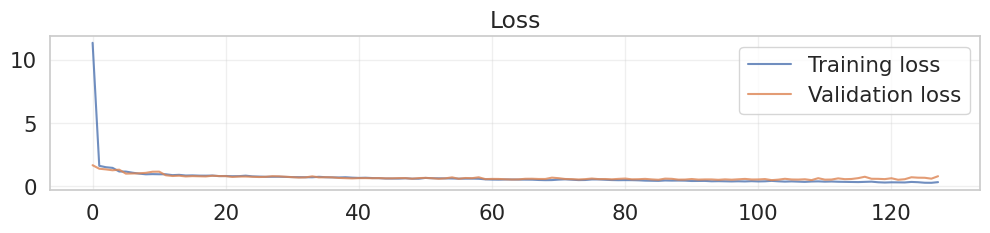

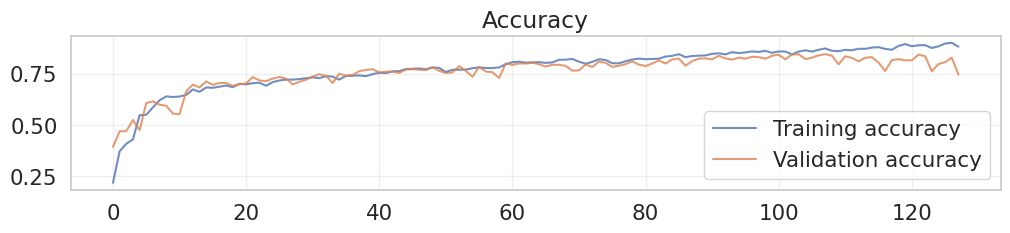

In [24]:
# Plot training and validation loss
plt.figure(figsize=(12, 2))
plt.plot(history['loss'], label='Training loss', alpha=.8)
plt.plot(history['val_loss'], label='Validation loss', alpha=.8)
plt.title('Loss')
plt.legend()
plt.grid(alpha=.3)

# Plot training and validation accuracy
plt.figure(figsize=(12, 2))
plt.plot(history['accuracy'], label='Training accuracy', alpha=.8)
plt.plot(history['val_accuracy'], label='Validation accuracy', alpha=.8)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=.3)
plt.show()